# 09. Denoising Diffusion Probabilistic Models

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-05-02">02 May 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/09_ddpm.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>

In the previous notebook, we studied [Variational Autoencoders (VAE)](../../notebooks/08_vae), where the model learns a latent variable $z$ and decodes it into an observation $x$. VAEs are just one way to model a generative process. Another method, which became extremely popular in the recent years due to their capacity, and has become default backbone of major image and video generation platforms is [Denoising Diffusion Probabilistic Model (DDPM)](https://en.wikipedia.org/wiki/Diffusion_model).

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
    The following source was consulted in preparing this material:
    <ul style="margin-top: 0;">
      <li>
        Ho, J., Jain, A., &amp; Abbeel, P. (2020).
        <a href="https://arxiv.org/abs/2006.11239">
          Denoising Diffusion Probabilistic Models</a>. NeurIPS 2020.
      </li>
    </ul>
  </p>
</div>

Similar to VAE and [transformer architecture](../../notebooks/07_transformer), we will be gradually building DDPM parts and then combine them for demonstration. In simple terms, DDPM generates an image step by step: it begins with pure Gaussian noise and gradually removes noise until a realistic sample appears. Its mechanism relies on a deep theory behind [probabilistic modeling](../../mathematics/05_prob_modeling), which we will ignore for the most part. Those who are interested in the fundamental mathematical reasoning behind DDPMs, can refer to books by [Goodfellow](https://www.deeplearningbook.org/) and [Murphy](https://probml.github.io/pml-book/book2.html). Here, we will limit ourselves with the knowledge we gained in the past lectures.

## Forward Process

The model is trained using augmented data generated through a fixed _forward process_. We will later see how a _reverse process_ learns to undo this corruption. For now, we only need to know that the forward process gradually adds Gaussian noise to a sampled data point $x_0 \sim q(x_0)$, where $q(x_0)$ denotes the real data distribution.

This process is predefined by us. It is not difficult to see that the generated augmented data is a Markov chain: each noisy image $x_t$ is produced from the previous noisy image $x_{t-1}$. As $t$ increases, the image keeps more noise and less original structure. If we continue this process for enough steps, the final image $x_T$ becomes close to pure Gaussian noise. Before seeing code implementation, let's understand how the DDPM paper defines the forward process and read the notation to get intuition.

$$
q(x_{1:T} \mid x_0) := \prod_{t=1}^{T} q(x_t \mid x_{t-1}),
\qquad
q(x_t \mid x_{t-1}) := \mathcal{N}
\left(
x_t;
\sqrt{1-\beta_t}x_{t-1},
\beta_t I
\right).
$$

Math seems complicated. It is. Here, however, $q(x_{1:T} \mid x_0)$ is basically the joint distribution of $x_1$ through $x_T$, and $\beta_t$ controls how much noise is added at timestep $t$. If $\beta_t$ is small, the next image is only slightly noisier than the previous image. If $\beta_t$ is large, the corruption is stronger. In other words, the equation says that $x_t$ is sampled from a Gaussian distribution whose mean is a slightly scaled version of the previous image $x_{t-1}$ and whose variance is controlled by $\beta_t$. To see what this equation does, let's rewrite the Gaussian transition:

$$
x_t = \sqrt{1-\beta_t}x_{t-1} + \sqrt{\beta_t}\epsilon_t,
\qquad
\epsilon_t \sim \mathcal{N}(0, I).
$$

Here, $\beta_t \in [0,1]$. For a small value of $\beta_t$ we will have the mean of every pixel value in $x_{t-1}$ to slightly shrunk toward zero, with a small Gaussian noise added. The shrinkage is controlled by $\sqrt{1-\beta_t}$, while the noise scale is controlled by $\sqrt{\beta_t}$.

<div class="admonition example">
  <p class="admonition-title">Example</p>
  <p style="margin: 0.5em 0;">
  For a single pixel, for example the top-left red-channel pixel, suppose its current normalized value is $x_{t-1}=0.80$. If $\beta_t = 0.02$, then

  $$
  \sqrt{1-\beta_t} = \sqrt{0.98} \approx 0.99,
  \qquad
  \sqrt{\beta_t} = \sqrt{0.02} \approx 0.14.
  $$

  So the conditional distribution of the next value is

  $$
  x_t \mid x_{t-1} \sim \mathcal{N}(0.99 \cdot 0.80,\; 0.02).
  $$

  The mean shifts from $0.80$ to about $0.792$, so the signal is slightly weakened. The variance becomes $0.02$, so the standard deviation is about $0.14$. A typical sampled value may therefore be around $0.792 \pm 0.14$, although Gaussian noise can sometimes push it further. The same operation is applied independently to every pixel and every channel. After one step, the image is still mostly recognizable. After many steps, the repeated shrinking and repeated noise injection gradually destroy the original structure.
  </p>
</div>

In [1]:
import torch

def forward_step(x, beta):
    return (1 - beta).sqrt()*x + beta.sqrt()*torch.randn_like(x)

def get_betas(T=1000, beta_start=1e-4, beta_end=0.02, device=None):
    return torch.linspace(beta_start, beta_end, T, device=device)

The code for a direct forward step is too simple. We see its influence in the input image below with a few preparations. We are already creating our functions to be suitable with `device` for future training. The function `get_betas()` creates the **variance schedule** of the forward diffusion process. In DDPM, the forward process does not add the same amount of noise at every step. Instead, it uses a sequence of values $\beta_1, \beta_2, \dots, \beta_T$. Each $\beta_t$ controls how much Gaussian noise is added at timestep $t$. We follow the original DDPM paper implementation, which set

$$
T = 1000,
\qquad
\beta_1 = 10^{-4},
\qquad
\beta_T = 0.02.
$$

The schedule is linear, so the values gradually increase from $10^{-4}$ to $0.02$. Later diffusion models often use improved schedules, such as cosine schedules, but the linear schedule is the cleanest starting point.

## CelebA Dataset

[CelebA](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) is a good dataset for a first DDPM implementation. It has many face images, and most of them have a similar structure: a human face near the center of the image. This makes it easier to train on than a general natural-image dataset where objects, scenes, and layouts vary much more. CelebA still contains 200K images with different identities, poses, appearances, and backgrounds. This makes it large enough for meaningful diffusion training, but still regular enough for early experiments. For this notebook, this is useful because we want to check whether the DDPM pipeline works before moving to harder datasets. If the model fails badly on CelebA, the problem is more likely to be in the implementation, training setup, noise schedule, or sampling code than in the dataset itself. Although CelebA can be loaded with `torchvision.datasets.CelebA`, this notebook reads it from a local folder. The torchvision version uses `gdown` for downloading, and the Google Drive download often fails because of quota limits.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/celeba.zip /content/
!mkdir -p /content/data
!unzip -q /content/celeba.zip -d /content/data/

In [4]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image

class SimpleImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.paths = sorted([p for p in Path(root).iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        x = Image.open(self.paths[i]).convert("RGB")
        x = self.transform(x) if self.transform else x
        return x

In [5]:
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

IMG_SIZE = 32
BATCH_SIZE = 256
NUM_WORKERS = 0
MAX_ITEMS = 10_000

transforms = transforms.Compose([transforms.ToTensor(), transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.Normalize([0.5]*3, [0.5]*3)])

data = SimpleImageFolder("./data/celeba", transforms)
data = Subset(data, range(min(MAX_ITEMS, len(data)))) if MAX_ITEMS is not None else data

loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

len(data), data[0].shape

(10000, torch.Size([3, 32, 32]))

We will be using a 10K-image subset of CelebA.  Many CelebA subsets can be found online as well. In this notebook, the images are resized to  stored at $32 \times 32$ to ease future computation. We only convert them to tensors and normalize pixel values from $[0,1]$ to $[-1,1]$, which is the range used by the DDPM model.

In [6]:
import torch, matplotlib.pyplot as plt

def show(xs, titles=None):
    if torch.is_tensor(xs):
        xs = list(xs) if xs.ndim == 4 else [xs]
    fig, ax = plt.subplots(1, len(xs), figsize=(3*len(xs), 3))
    ax = ax if len(xs) > 1 else [ax]
    for i, x in enumerate(xs):
        x = ((x.detach().cpu()+1)/2).clamp(0,1).permute(1,2,0)
        ax[i].imshow(x); ax[i].axis("off")
        if titles: ax[i].set_title(titles[i])
    plt.show()

For visualization purposes, we will modify default setting of the schedule.

In [7]:
T = 4
beta_start = 0.03
beta_end = 0.3

betas = get_betas(T, beta_start, beta_end)

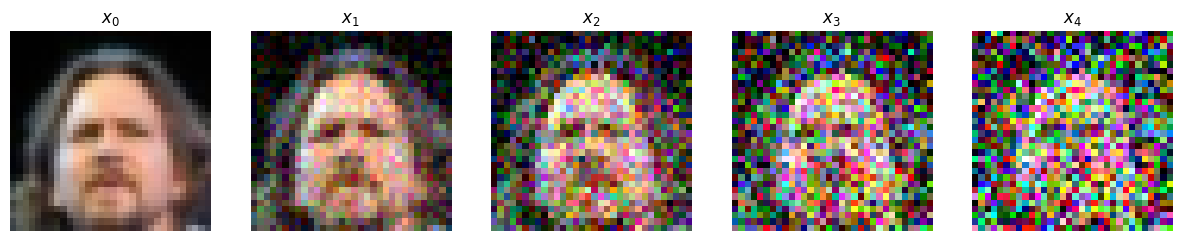

In [8]:
x_orig = data[7]
x = x_orig.clone() # so that x_orig will not be overridden

xs = [x_orig]
for t in range(T):
  x_next = forward_step(x, betas[t])
  xs.append(x_next)
  x = x_next

show(torch.stack(xs), [fr"$x_{{{t}}}$" for t in range(T+1)])

## Forward Sampling

The forward process is defined step by step, but during training we do not want to compute $x_1, x_2, \ldots, x_t$ one by one. That would be slow, especially when $t$ is large. It would be great if we could somehow choose a random timestep $t$, create $x_t$ directly from $x_0$, and train the model to predict the noise that was added. It turns out this is possible. If we define $\alpha_t = 1-\beta_t$, then the forward step can be written as

$$
x_t = \sqrt{\alpha_t}x_{t-1} + \sqrt{1-\alpha_t}\epsilon_t, \qquad \epsilon_t \sim \mathcal{N}(0,I).
$$

This may seem meaningless, but it makes the derivation cleaner. In the paper, the formula appears suddenly. We will derive it step by step. For $t=1$,

$$
x_1 = \sqrt{\alpha_1}x_0 + \sqrt{1-\alpha_1}\epsilon_1.
$$

For $t=2$, substitute the expression for $x_1$:

$$
x_2 = \sqrt{\alpha_2}\left(\sqrt{\alpha_1}x_0 + \sqrt{1-\alpha_1}\epsilon_1\right) + \sqrt{1-\alpha_2}\epsilon_2.
$$

After expanding, the clean image has coefficient $\sqrt{\alpha_1\alpha_2}$. The noise part is a weighted sum of two independent Gaussian noise terms. Since a weighted sum of independent Gaussian variables is still Gaussian, we can collapse the two noise terms into one noise term. Its variance is the sum of the squared coefficients:

$$
\alpha_2(1-\alpha_1) + (1-\alpha_2) = 1-\alpha_1\alpha_2.
$$

So after two steps, the whole expression can be written as

$$
x_2 = \sqrt{\alpha_1\alpha_2}x_0 + \sqrt{1-\alpha_1\alpha_2}\epsilon.
$$

This already shows the pattern. The product $\alpha_1\alpha_2$ controls how much of the original image remains. The remaining part, $1-\alpha_1\alpha_2$, becomes the noise variance. For $t=3$, the same thing happens again: the image coefficient receives another multiplication by $\alpha_3$, and the noise variance becomes the remaining part, $1-\alpha_1\alpha_2\alpha_3$. Therefore, after $t$ steps, we define

$$
\bar{\alpha}_t = \prod_{s=1}^{t}\alpha_s.
$$

Then the direct sampling formula becomes

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon, \qquad \epsilon \sim \mathcal{N}(0,I).
$$

Equivalently,

$$
q(x_t \mid x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1-\bar{\alpha}_t)I).
$$

This formula means that we do not need to simulate all intermediate steps. We can compute $\bar{\alpha}_t$, sample one Gaussian noise tensor $\epsilon$, and create $x_t$ directly. We will now implement the forward sampling function from this formula and verify that it gives the same output as the earlier step-by-step function.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 0.5em 0;">
  If $z = a\epsilon_1 + b\epsilon_2$, where $\epsilon_1$ and $\epsilon_2$ are independent standard Gaussian noises, then $z$ is also Gaussian. Its variance is
  $$
  \mathrm{Var}(z)=a^2\mathrm{Var}(\epsilon_1)+b^2\mathrm{Var}(\epsilon_2)+2ab\,\mathrm{Cov}(\epsilon_1,\epsilon_2).
  $$
  Because the noises are independent, the covariance term is $0$. Since both noises have variance $1$, we get
  $$
  \mathrm{Var}(z)=a^2+b^2.
  $$
  This is why the variance of the combined noise is the sum of the squared coefficients.
  </p>
</div>

In [9]:
def forward_sample(x0, betas, t, eps=None):
  eps = torch.randn_like(x0) if eps is None else eps
  alpha_bar = torch.cumprod(1 - betas, dim=0)
  if not torch.is_tensor(t):
      t = torch.tensor(t, device=x0.device, dtype=torch.long)
  else:
      t = t.to(device=x0.device, dtype=torch.long)
  alpha_bar_t = alpha_bar[t]
  while alpha_bar_t.ndim < x0.ndim:
      alpha_bar_t = alpha_bar_t[..., None]
  return alpha_bar_t.sqrt() * x0 + (1 - alpha_bar_t).sqrt() * eps

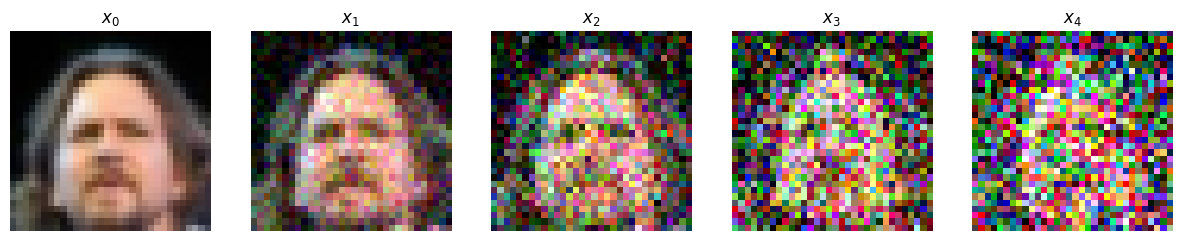

In [10]:
xs = [x_orig]
for t in range(T):
  x_t = forward_sample(x_orig, betas, t)
  xs.append(x_t)

show(torch.stack(xs), [fr"$x_{{{t}}}$" for t in range(T+1)])

## Reverse Process

We have now defined the forward process. It takes a clean image $x_0$ and gradually turns it into noise:

$$
x_0 \rightarrow x_1 \rightarrow x_2 \rightarrow \cdots \rightarrow x_T.
$$

The forward process is easy because we define it manually. We choose the noise schedule $\beta_t$, and then we know exactly how to sample $x_t$ from $x_{t-1}$ or directly from $x_0$. This is useful for training, because we can create noisy examples ourselves. However, this is not yet generation. Generation needs the opposite direction. We want to start from pure Gaussian noise and gradually recover an image:

$$
x_T \rightarrow x_{T-1} \rightarrow x_{T-2} \rightarrow \cdots \rightarrow x_0.
$$

This is called the _reverse process_. The reverse process is way harder. Given a noisy image $x_t$, we want to know what the slightly less noisy image $x_{t-1}$ should be. In probabilistic form, this is a Markov chain as we want $p_\theta(x_{t-1} \mid x_t)$. Here, the subscript $\theta$ means that this distribution will be parametrized and learned by a neural network.

<figure>
  <img src="../../assets/images/diffusion/ddpm.png" alt="DDPM directed graphical model" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Directed graphical model of DDPM ~ Ho et al., <a href="https://arxiv.org/abs/2006.11239">Denoising Diffusion Probabilistic Models</a>, <a href="https://arxiv.org/pdf/2006.11239.pdf">Fig. 2</a>.
  </figcaption>
</figure>

The true reverse distribution is not directly known. We know how we corrupted the image, but recovering the previous step requires information about the data distribution. For example, if a noisy patch could correspond to many possible clean image patches, the model has to learn which ones are realistic. So the main learning problem is this: _given $x_t$ and the timestep $t$, predict enough information to move one step backward toward $x_0$._ In the paper, the reverse step is also written as a Gaussian transition:

$$
p_\theta(x_{t-1} \mid x_t)
=
\mathcal{N}
\left(
x_{t-1};
\mu_\theta(x_t,t),
\Sigma_\theta(x_t,t)
\right).
$$

This Gaussian form means that, at every reverse step, we need to decide two things: the mean and the variance. The mean tells us where the previous image $x_{t-1}$ is centered. In other words, it tells us the model's best guess of the slightly less noisy image. The variance tells us how much randomness to keep in the reverse step. If the variance is large, the reverse step is more random. If it is small, the reverse step is more deterministic.

So the neural network could predict both $\mu_\theta(x_t,t)$ and $\Sigma_\theta(x_t,t)$. However, the original DDPM setup usually keeps the variance simple. Instead of asking the network to learn a full variance function, the variance is again fixed using the noise schedule. This leaves the neural network mainly responsible for the mean.

A natural idea therefore is to train the network to predict the mean directly. That simply means giving the model $x_t$ and $t$, and asking it to output $\mu_\theta(x_t,t)$. But it turns out there is a more convenient equivalent for parameterization. Instead of predicting the reverse mean directly, the model predicts the noise $\epsilon$ that was used to create $x_t$ from $x_0$. This makes sense because the forward sample was created by

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon.
$$

During training, we know $x_0$, we choose $t$, and we sample $\epsilon$ ourselves. Therefore, after constructing $x_t$, we also know the exact noise that was added. This gives a direct supervised learning problem:

$$
(x_t,t) \longrightarrow \epsilon.
$$

The input is the noisy image and the timestep. The target is the noise used to corrupt the image. So the model is trained to predict the noise inside $x_t$:

$$
\epsilon_\theta(x_t,t) \approx \epsilon.
$$

We ultimately want to generate images, not noise. But predicting noise is useful because the noise tells us how to move back from $x_t$ toward the clean image. We can also see this directly from the forward formula. If the model predicts $\epsilon$, then we can estimate the clean image direction by rearranging the equation:

$$
x_0
=
\frac{x_t - \sqrt{1-\bar{\alpha}_t}\epsilon}{\sqrt{\bar{\alpha}_t}}.
$$

During sampling, we do not know the true $\epsilon$, so we use the model prediction:

$$
\hat{x}_0
=
\frac{x_t - \sqrt{1-\bar{\alpha}_t}\epsilon_\theta(x_t,t)}{\sqrt{\bar{\alpha}_t}}.
$$

Hence the model outputs the noise estimate, and from that noise estimate we can compute a direction toward $x_0$. This predicted noise can then be used to compute the reverse mean and move from $x_t$ to $x_{t-1}$.

### U-Net and Time Encoding

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
  If you already know about U-Net architecture, you may want to skip this section. However, the integration of time encoding could be something new even if you know about U-Net.
  </p>
</div>

Now we have a clearer idea of what the neural network has to do. It receives a noisy image $x_t$ and a timestep $t$, and it must output something with the same shape as the image. In the DDPM version we are following, this output will be the predicted noise:

$$
\epsilon_\theta(x_t,t).
$$

We now need to choose an appropriate model. In the original paper, the reverse process is parameterized with a U-Net-like model. The original **U-Net** architecture ([Ronneberger et al., 2015](https://arxiv.org/abs/1505.04597)) was introduced for biomedical image segmentation. Its basic idea is simple: use a contracting path to capture context, then use an expanding path to recover spatial resolution. This fits _image-to-image_ problems well because the input and output are both spatial tensors. You should be already familiar with such an encoder-decoder architecture from [sequence-to-sequence](../../notebooks/06_rnn_sequential) modeling.

A U-Net first reduces the spatial resolution while increasing the number of channels. This lets the model capture larger-scale structure. Then it increases the resolution again to return to the original image size. The important detail is the [skip connections](../../notebooks/05_cnn_architectures/#residual-network) between matching resolutions. These connections pass high-resolution features from the encoder side to the decoder side. This matters because denoising needs both global structure and local detail.

<figure>
  <img src="../../assets/images/diffusion/unet.png" alt="U-Net Architecture" style="max-width: 80%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    <p>U-Net architecture, Figure 1 from <em>U-Net: Convolutional Networks for Biomedical Image Segmentation</em> by Olaf Ronneberger, Philipp Fischer, and Thomas Brox, 2015. Source: <a href="https://arxiv.org/abs/1505.04597">arXiv:1505.04597</a>.</p>
  </figcaption>
</figure>

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 0.5em 0;">
  Not all modern diffusion models must use U-Net. More recent models can use transformer backbones instead. For example, Diffusion Transformers (DiT) <a href='https://arxiv.org/abs/2212.09748'>(Peebles and Xie, 2023)</a> replace the commonly used U-Net backbone with a transformer operating on latent image patches. Still, for a basic DDPM implementation, U-Net is the cleanest architecture to study first.
  </p>
</div>

You can find a custom U-Net code in this [DDPM implementation from scratch](https://github.com/shahaliyev/ddpm/blob/main/model.py). Before using a ready U-Net, however, it is useful to clarify one building block that may look unfamiliar from the figure: the up-convolution, also called transposed convolution. All others we have already seen earlier notebooks.

<figure>
  <img src="../../assets/images/diffusion/trans_conv.svg" alt="Transposed convolution with a 2 by 2 kernel" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Transposed convolution with a \(2 \times 2\) kernel ~ Zhang et al., <a href="https://d2l.ai/">Dive into Deep Learning</a>, <a href="https://d2l.ai/chapter_computer-vision/transposed-conv.html">Fig. 14.10.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

In the encoder side of a U-Net, the spatial size is reduced. For example, an image feature map may go from $64 \times 64$ to $32 \times 32$, then to $16 \times 16$. In the decoder side, we need to go in the opposite direction and increase the spatial size again. One way to do this is `ConvTranspose2d`. A normal convolution often reduces spatial size when `stride=2`. A transposed convolution can learn the reverse kind of operation: it increases spatial size while also changing the number of channels. In practice, if we use `kernel_size=4`, `stride=2`, and `padding=1`, then the height and width are doubled. So a tensor with shape $(B, C, 32, 32)$ can become $(B, C', 64, 64)$. Below is a toy example.


In [11]:
def conv_transpose2d(x, kernel, stride):
  H, W = x.shape
  K_h, K_w = kernel.shape

  out_h = (H - 1) * stride + K_h
  out_w = (W - 1) * stride + K_w

  out = torch.zeros(out_h, out_w)
  for i in range(H):
      for j in range(W):
          out[i*stride:i*stride+K_h, j*stride:j*stride+K_w] += x[i, j] * kernel
  return out

In [12]:
x = torch.tensor([
    [0.0, 1.0],
    [2.0, 3.0]
])

kernel = torch.tensor([
    [0.0, 1.0],
    [2.0, 3.0]
])

conv_transpose2d(x, kernel, stride=1)

tensor([[ 0.,  0.,  1.],
        [ 0.,  4.,  6.],
        [ 4., 12.,  9.]])


For diffusion, we said that $x_t$ alone is not enough. The model also needs to know the timestep. At small $t$, the image is only slightly noisy, so the model should make a small correction. At large $t$, the image is heavily corrupted, so the model must rely much more on learned image structure. The same network must therefore behave differently depending on $t$. But how do we inject time information into our model? Recall the [positional encoding](../../notebooks/07_transformer/#positional-encoding) of the Transformer architecture.

The scalar timestep $t$ is converted into a vector, usually with sinusoidal embeddings followed by a small [MLP](../../notebooks/02_neural_network).   DDPM uses sinusoidal positional encoding. Later diffusion models refine how this timestep information is used, however, for our basic DDPM, sinusoidal embedding plus MLP is more than enough. Recall that, for an embedding dimension $d$, the sinusoidal timestep embedding can be written as

$$
\mathrm{emb}(t) =
\left[
\sin(t\omega_0), \ldots, \sin(t\omega_{d/2-1}),
\cos(t\omega_0), \ldots, \cos(t\omega_{d/2-1})
\right],
$$

where the frequencies are usually chosen as

$$
\omega_i = 10000^{-i/(d/2-1)}.
$$

This turns a scalar timestep into a vector containing both low-frequency and high-frequency information. Nearby timesteps get related embeddings, but the network can still distinguish different noise levels.

In [13]:
import torch.nn as nn

class TimeEmbedding(nn.Module):
  def __init__(self, emb_dim, hidden_dim=None):
    super().__init__()
    assert emb_dim % 2 == 0
    hidden_dim = emb_dim * 4 if hidden_dim is None else hidden_dim
    self.emb_dim = emb_dim
    self.mlp = nn.Sequential(
      nn.Linear(emb_dim, hidden_dim),
      nn.SiLU(),
      nn.Linear(hidden_dim, hidden_dim),
    )

  def forward(self, t):
    half = self.emb_dim // 2
    freqs = torch.exp(
      -torch.log(torch.tensor(10000.0)) * torch.arange(half) / (half - 1)
    )
    args = t.float()[:, None] * freqs[None, :]
    emb = torch.cat([args.sin(), args.cos()], dim=-1)
    return self.mlp(emb)

The class above converts the scalar timestep $t$ into a fixed sinusoidal vector. Then it passes that vector through a small MLP. The sinusoidal part gives the model a structured representation of time, while the MLP lets the network reshape that representation into refined features (recall [positionwise feedforward network](../../notebooks/07_transformer/#positionwise-feed-forward-networks)).


<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 0.5em 0;">
  The activation used inside the MLP is <code>SiLU</code>, also called <em>Swish</em>, which can seem something new. It is basically
  $$
  \mathrm{SiLU}(x)=x\sigma(x),
  $$
  where $\sigma(x)$ is the sigmoid function. We will not spend much time on activation choices here. At this point we risk diverging from the main discussion a lot.
  </p>
</div>

In [14]:
time_emb = TimeEmbedding(emb_dim=8)

t = torch.tensor([0, 1, 10, 100])
time_vec = time_emb(t)

time_vec.shape

torch.Size([4, 32])

The function receives a batch of timesteps such as and returns one vector per timestep. If the embedding dimension is $d=8$, then each timestep becomes an $8$-dimensional vector: 4 sine values and 4 cosine values. For the actual DDPM model, we will use the ready Hugging Face [UNet2DModel](https://huggingface.co/docs/diffusers/api/models/unet2d). It already implements a diffusion-style U-Net: it receives a noisy image and a timestep, injects timestep information internally, and returns an image-shaped output. This lets us focus on the diffusion logic: forward noising, noise prediction loss, training loop, and sampling.

In [15]:
!pip install -q diffusers # installing diffusers for importing U-Net

In [16]:
from diffusers import UNet2DModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Training Objective

We now know what the model should take as input and what should be the output. The remaining question is: _what is the training objective, and where does the loss function come from?_ Similar to VAE, in DDPM, the loss comes from likelihood-based training through a variational bound. The training objective is to make the model assign high probability to real images $x_0$. In other words, we want to maximize $p_\theta(x_0)$, or, equivalently, we want to minimize the negative log-likelihood: $-\log p_\theta(x_0)$. If we look at diffusion models more carefully, to our surprise, we may realize that diffusion process actually introduces many **latent variables** through augmentation and he reverse model generates $x_0$ through a whole chain of latent variables:

$$
x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0.
$$

So if we want the probability of a real image $x_0$, we would need to consider all possible noisy paths that could have produced it:

$$
p_\theta(x_0)
=
\int p_\theta(x_{0:T})\,dx_{1:T}.
$$

This marginalization is intractable. This is the same basic problem we had in VAEs: the model has latent variables, and exact likelihood computation is difficult. So instead of optimizing the exact negative log-likelihood directly, we optimize a variational upper bound on it. To build that bound, we need a distribution over latent paths given the observed image $x_0$. In VAEs, this role is played by the encoder $q_\phi(z\mid x)$. In DDPM, we do not learn this encoder. We already have a fixed forward process:

$$
q(x_{1:T}\mid x_0).
$$

The forward process plays the role of the **approximate posterior**. It tells us how to produce the noisy latent chain from the clean image. We introduce the known forward process $q(x_{1:T}\mid x_0)$ and multiply/divide by it inside the integral:

$$
p_\theta(x_0)
=
\int
q(x_{1:T}\mid x_0)
\frac{
p_\theta(x_{0:T})
}{
q(x_{1:T}\mid x_0)
}
\,dx_{1:T}.
$$

We can rewrite it as an expectation over the forward process and take log on both sides:

$$
\log p_\theta(x_0)
=
\log
\mathbb{E}_{q(x_{1:T}\mid x_0)}
\left[
\frac{
p_\theta(x_{0:T})
}{
q(x_{1:T}\mid x_0)
}
\right].
$$

From [Jensen's inequality](https://en.wikipedia.org/wiki/Jensen%27s_inequality), because $\log$ is concave, the log of an expectation is greater than or equal to the expectation of the log:

$$
\log p_\theta(x_0)
\geq
\mathbb{E}_{q(x_{1:T}\mid x_0)}
\left[
\log
\frac{
p_\theta(x_{0:T})
}{
q(x_{1:T}\mid x_0)
}
\right].
$$

This lower bound is the [ELBO](../../notebooks/08_vae/#evidence-lower-bound-elbo). Since training usually minimizes a loss, we multiply by $-1$ and get the negative ELBO. So instead of minimizing the intractable negative log-likelihood directly, DDPM minimizes the tractable upper bound

$$
\mathcal{L}
=
\mathbb{E}_q
\left[
-\log
\frac{
p_\theta(x_{0:T})
}{
q(x_{1:T}\mid x_0)
}
\right].
$$

To rewrite this equation further, we use the Markov structure of both processes. The forward process is

$$
q(x_{1:T}\mid x_0)
=
\prod_{t=1}^{T} q(x_t\mid x_{t-1}),
$$

and the reverse generative model is

$$
p_\theta(x_{0:T})
=
p(x_T)
\prod_{t=1}^{T}p_\theta(x_{t-1}\mid x_t).
$$

Substituting these into the negative ELBO gives

$$
\mathcal{L}
=
\mathbb{E}_q
\left[
-\log p(x_T)
-
\sum_{t=1}^{T}\log p_\theta(x_{t-1}\mid x_t)
+
\sum_{t=1}^{T}\log q(x_t\mid x_{t-1})
\right].
$$

This expression is correct, but it is not yet in the most useful form. The problem is that the forward terms are written as $q(x_t\mid x_{t-1})$, while the reverse model terms are written as $p_\theta(x_{t-1}\mid x_t)$.To compare the true reverse step with the learned reverse step, we want terms involving $q(x_{t-1}\mid x_t,x_0)$.

This posterior means: if we know the clean image $x_0$ and the noisy image $x_t$, what is the distribution of the previous noisy image $x_{t-1}$? During training this is allowed, because $x_0$ is known. The useful identity is that the forward chain can be rearranged as

$$
q(x_{1:T}\mid x_0)
=
q(x_T\mid x_0)
\prod_{t=2}^{T}
q(x_{t-1}\mid x_t,x_0).
$$

This is just the same forward path written backwards while still conditioning on $x_0$. It does not mean the forward process runs backward. It only means we are rewriting the probability of the same latent path. Taking logs gives

$$
\log q(x_{1:T}\mid x_0)
=
\log q(x_T\mid x_0)
+
\sum_{t=2}^{T}
\log q(x_{t-1}\mid x_t,x_0).
$$

Now substitute this version into the negative ELBO:

$$
\mathcal{L}
=
\mathbb{E}_q
\left[
\log q(x_T\mid x_0)
-
\log p(x_T)
+
\sum_{t=2}^{T}
\left(
\log q(x_{t-1}\mid x_t,x_0)
-
\log p_\theta(x_{t-1}\mid x_t)
\right)
-
\log p_\theta(x_0\mid x_1)
\right].
$$

Now the KL terms are visible. Therefore the DDPM objective can be written as

$$
\mathcal{L}
=
\mathbb{E}_q
\left[
L_T
+
\sum_{t>1}L_{t-1}
+
L_0
\right],
$$

where

$$
L_T
=
D_{\mathrm{KL}}
\left(
q(x_T\mid x_0)
\;\|\;
p(x_T)
\right),
$$

$$
L_{t-1}
=
D_{\mathrm{KL}}
\left(
q(x_{t-1}\mid x_t,x_0)
\;\|\;
p_\theta(x_{t-1}\mid x_t)
\right),
$$

$$
L_0
=
-\log p_\theta(x_0\mid x_1).
$$


So each middle loss term says: make the learned reverse transition close to the true reverse posterior. The first term, $L_T$, compares the final noisy distribution with the prior $p(x_T)$. If the noise schedule is chosen well, $x_T$ is almost standard Gaussian, so this term does not require learning. The last term, $L_0$, handles the final reconstruction from $x_1$ to $x_0$. The middle terms are the main part for learning the reverse process.

Hence it is not the end of the story. The question becomes: how do we compute $q(x_{t-1}\mid x_t,x_0)?$ During training, we know both $x_0$ and $x_t$, so we can ask: given the clean image and the current noisy image, what should the previous noisy image $x_{t-1}$ look like? By Bayes' rule,

$$
q(x_{t-1}\mid x_t,x_0)
\propto
q(x_t\mid x_{t-1},x_0)q(x_{t-1}\mid x_0).
$$

Because the forward process is Markov, $x_t$ depends only on $x_{t-1}$, not directly on $x_0$. Therefore,

$$
q(x_t\mid x_{t-1},x_0)=q(x_t\mid x_{t-1}),
$$

so

$$
q(x_{t-1}\mid x_t,x_0)
\propto
q(x_t\mid x_{t-1})q(x_{t-1}\mid x_0).
$$

Both terms on the right are Gaussian. The one-step forward transition is

$$
q(x_t\mid x_{t-1})
=
\mathcal{N}
\left(
x_t;
\sqrt{\alpha_t}x_{t-1},
\beta_t I
\right),
$$

and the direct forward distribution at timestep $t-1$ is

$$
q(x_{t-1}\mid x_0)
=
\mathcal{N}
\left(
x_{t-1};
\sqrt{\bar{\alpha}_{t-1}}x_0,
(1-\bar{\alpha}_{t-1})I
\right).
$$

A product of Gaussian terms is again Gaussian. Therefore,

$$
q(x_{t-1}\mid x_t,x_0)
=
\mathcal{N}
\left(
x_{t-1};
\tilde{\mu}_t(x_t,x_0),
\tilde{\beta}_t I
\right).
$$

If we multiply the two Gaussian factors above and collect the terms involving $x_{t-1}$, the posterior mean becomes

$$
\tilde{\mu}_t(x_t,x_0)
=
\frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1-\bar{\alpha}_t}x_0
+
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t.
$$

Recall the expression

$$
x_0
=
\frac{x_t-\sqrt{1-\bar{\alpha}_t}\epsilon}{\sqrt{\bar{\alpha}_t}}.
$$

Now substitute this expression for $x_0$ into the posterior mean:

$$
\tilde{\mu}_t(x_t,x_0)
=
\frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1-\bar{\alpha}_t}
\left(
\frac{x_t-\sqrt{1-\bar{\alpha}_t}\epsilon}{\sqrt{\bar{\alpha}_t}}
\right)
+
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t.
$$

Since $\bar{\alpha}_t=\alpha_t\bar{\alpha}_{t-1}$, we have $
\frac{\sqrt{\bar{\alpha}_{t-1}}}{\sqrt{\bar{\alpha}_t}}
=
\frac{1}{\sqrt{\alpha_t}}$. So the expression becomes

$$
\tilde{\mu}_t(x_t,\epsilon)
=
\frac{\beta_t}{\sqrt{\alpha_t}(1-\bar{\alpha}_t)}
\left(
x_t-\sqrt{1-\bar{\alpha}_t}\epsilon
\right)
+
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t.
$$

Separating the $x_t$ and $\epsilon$ terms gives

$$
\tilde{\mu}_t(x_t,\epsilon)
=
\left[
\frac{\beta_t}{\sqrt{\alpha_t}(1-\bar{\alpha}_t)}
+
\frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}
\right]x_t
-
\frac{\beta_t}{\sqrt{\alpha_t}\sqrt{1-\bar{\alpha}_t}}\epsilon.
$$

The two $x_t$ coefficients combine into $\frac{1}{\sqrt{\alpha_t}}$. Therefore,

$$
\tilde{\mu}_t(x_t,\epsilon)
=
\frac{1}{\sqrt{\alpha_t}}x_t
-
\frac{\beta_t}{\sqrt{\alpha_t}\sqrt{1-\bar{\alpha}_t}}\epsilon.
$$

Factoring out $\frac{1}{\sqrt{\alpha_t}}$, we get

$$
\tilde{\mu}_t(x_t,\epsilon)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon
\right).
$$

The true posterior mean is now written using the noise $\epsilon$. During training, $\epsilon$ is known because we sampled it ourselves. During sampling, $\epsilon$ is unknown, so DDPM trains a neural network to predict it: $\epsilon_\theta(x_t,t)\approx \epsilon$. Then the learned reverse mean is written as

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\epsilon_\theta(x_t,t)
\right).
$$

If the variance of the learned reverse process is fixed, then the only learned part is the mean. For two Gaussians with fixed variance, the KL term depends on the squared distance between their means. So, up to terms that do not depend on the network parameters,

$$
L_{t-1}
=
\mathbb{E}_q
\left[
\frac{1}{2\sigma_t^2}
\left\|
\tilde{\mu}_t(x_t,x_0)
-
\mu_\theta(x_t,t)
\right\|^2
\right]
+
C.
$$

Now we use the noise-based form of the two means and subtract them. The $x_t$ terms cancel:

$$
\tilde{\mu}_t(x_t,\epsilon)
-
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon
+
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t,t)
\right).
$$

So

$$
\tilde{\mu}_t(x_t,\epsilon)
-
\mu_\theta(x_t,t)
=
\frac{\beta_t}{\sqrt{\alpha_t}\sqrt{1-\bar{\alpha}_t}}
\left(
\epsilon_\theta(x_t,t)-\epsilon
\right).
$$

Taking the squared norm gives

$$
\left\|
\tilde{\mu}_t(x_t,\epsilon)
-
\mu_\theta(x_t,t)
\right\|^2
=
\frac{\beta_t^2}{\alpha_t(1-\bar{\alpha}_t)}
\left\|
\epsilon-\epsilon_\theta(x_t,t)
\right\|^2.
$$

Substituting this back into the Gaussian KL term gives

$$
L_{t-1}
=
\mathbb{E}_{x_0,\epsilon}
\left[
\frac{\beta_t^2}{2\sigma_t^2\alpha_t(1-\bar{\alpha}_t)}
\left\|
\epsilon-\epsilon_\theta(x_t,t)
\right\|^2
\right]
+
C.
$$

This is the weighted noise-prediction objective. The weight is

$$
w_t
=
\frac{\beta_t^2}{2\sigma_t^2\alpha_t(1-\bar{\alpha}_t)}.
$$

So the weighted objective is

$$
\mathbb{E}_{x_0,\epsilon,t}
\left[
w_t
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|^2
\right].
$$


The original DDPM paper then uses a simplified version by dropping this timestep-dependent weight:

$$
\mathcal{L}_{simple}
=
\mathbb{E}_{x_0,\epsilon,t}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|^2
\right].
$$

The joke is that, this final expression becomes MSE between the true noise and the predicted noise. For each batch, we sample $t$, sample $\epsilon$, construct $x_t$, predict $\epsilon_\theta(x_t,t)$, and compute the loss.

## Training DDPM

Diffusion training is slow because, at every step, we must sample a timestep $t$, generate $x_t$, run the U-Net, and predict the noise. If we train on many classes at once, the model has to learn a broader distribution, which usually needs more time. So here we make a deliberate simplification. CelebeA images are already relatively small, $64\times64$, so we can technically keep the original resolution instead of resizing to $32\times32$ (which we do for faster training). CelebA dataset also has less variation than many other datasets, so the model can learn the data distribution faster. This is useful for learning, where we want to see the whole DDPM pipeline end to end, including sampling, without waiting too long. We also restrict the dataset to have only 10K images, which is enough for diffusion to learn a rough distribution for sampling. Longer training and full dataset will naturally improve the sampling outputs while making the training slower.

Now we can train the model with the simplified DDPM objective. Each iteration follows the same pattern: take a clean image batch $x_0$, sample a random timestep $t$, sample Gaussian noise $\epsilon$, create $x_t$ using `forward_sample`, and train the U-Net to predict $\epsilon$ from $(x_t,t)$. The `tqdm` progress bar is only for monitoring. It shows the current epoch progress and displays the current loss while training. It does not affect the model.

**Automatic Mixed Precision (AMP)** accelerates training by using lower numerical precision where it is safe, while preserving stability where needed. In practice, most of the forward pass runs in `float16`, which reduces memory usage and increases throughput on modern GPUs, while sensitive operations remain in `float32` to avoid numerical errors. During backpropagation, gradients can become very small in `float16`, so PyTorch uses a technique called loss scaling: the loss is temporarily multiplied by a large factor before computing gradients, and then scaled back before the optimizer step. This is handled automatically through `autocast` (which manages precision during the forward pass) and `GradScaler` (which manages stable gradient updates). Importantly, AMP does not change the DDPM objective or training logic; it only makes the same training loop more efficient, typically resulting in faster training and lower memory consumption.

In [17]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm.auto import tqdm

T = 1000
EPOCHS = 50
LR = 2e-4

device = torch.device(device)

betas = get_betas(T=T, device=device)
model = model.to(device)
optimizer = AdamW(model.parameters(), lr=LR)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

model.train()
losses = []
epoch_losses = []

for e in range(EPOCHS):
    pbar = tqdm(loader, desc=f"Epoch {e+1}/{EPOCHS}")
    running_loss = 0.0

    for x0 in pbar:
        x0 = x0.to(device, non_blocking=True)

        t = torch.randint(0, T, (x0.shape[0],), device=device)
        eps = torch.randn_like(x0)

        with torch.amp.autocast("cuda", enabled=use_amp):
            xt = forward_sample(x0, betas, t, eps)
            eps_pred = model(xt, t).sample
            loss = F.mse_loss(eps_pred, eps)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_value = loss.item()
        losses.append(loss_value)
        running_loss += loss_value

        pbar.set_postfix(loss=loss_value)

    avg_loss = running_loss / len(loader)
    epoch_losses.append(avg_loss)
    print(f"epoch={e+1} avg_loss={avg_loss:.6f}")

Epoch 1/50:   0%|          | 0/40 [00:00<?, ?it/s]

epoch=1 avg_loss=0.261792


Epoch 2/50:   0%|          | 0/40 [00:00<?, ?it/s]

epoch=2 avg_loss=0.089429


Epoch 3/50:   0%|          | 0/40 [00:00<?, ?it/s]

...

epoch=48 avg_loss=0.026048


Epoch 49/50:   0%|          | 0/40 [00:00<?, ?it/s]

epoch=49 avg_loss=0.026662


Epoch 50/50:   0%|          | 0/40 [00:00<?, ?it/s]

epoch=50 avg_loss=0.027225


<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
     As mkdocs couldn't convert tqdm widgets from ipynb to markdown, I had to clear cell outputs for training. The average loss at the last epoch was around 0.027.
  </p>
</div>

## Sampling

Training taught the model to solve the supervised task $(x_t,t)\mapsto \epsilon$. Sampling is where we use this learned noise predictor to actually generate images. Similar to VAE, we start from pure Gaussian noise, $x_T \sim \mathcal{N}(0,I)$, and then run the reverse process step by step,

$$
x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0.
$$

At each timestep $t$, we need a rule for moving from $x_t$ to $x_{t-1}$. This rule comes from the posterior of the forward process. Since the forward transition is Gaussian,
$$
q(x_t \mid x_{t-1}) = \mathcal{N}(\sqrt{\alpha_t}x_{t-1}, \beta_t I),
$$
the conditional distribution $q(x_{t-1} \mid x_t, x_0)$ is also Gaussian and provides the exact backward step if the clean image $x_0$ were known. However, during sampling we do not know $x_0$, so we estimate it using the model. From the forward equation
$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,
$$
we express $x_0$ in terms of $x_t$ and $\epsilon$, and replace $\epsilon$ with the model prediction $\epsilon_\theta(x_t,t)$,
$$
\hat{x}_0 =
\frac{1}{\sqrt{\bar{\alpha}_t}}
\left(
x_t - \sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta(x_t,t)
\right).
$$

Plugging this estimate into the posterior yields the reverse mean
$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
\epsilon_\theta(x_t,t)
\right),
$$
and the variance is taken directly from the posterior,
$$
\tilde{\beta}_t = \beta_t \frac{1-\bar{\alpha}_{t-1}}{1-\bar{\alpha}_t}.
$$
We then sample
$$
x_{t-1}
=
\mu_\theta(x_t,t)
+
\sqrt{\tilde{\beta}_t}z,
\qquad z\sim\mathcal{N}(0,I),
$$
for $t>0$, and omit noise at $t=0$. The overall procedure is therefore to start from random noise, repeatedly predict the noise component, apply the posterior-based update, and iterate until $x_0$ is reached. In practice, this requires evaluating the model for every timestep, so generating a single image with $T=1000$ requires 1000 sequential steps, which makes sampling much slower than training.

This slow sampling procedure motivated a large body of follow-up work focused on improving efficiency. A key example is DDIM, which replaces the stochastic reverse chain with a non-Markovian, partially deterministic process that can produce samples $10\times$–$50\times$ faster while keeping similar quality ([Song et al., 2020](https://arxiv.org/abs/2010.02502)). Later work shows that the diffusion process can also be interpreted as a continuous-time stochastic differential equation, allowing sampling to be reformulated as solving an ODE or SDE with far fewer steps ([Song et al., 2020](https://arxiv.org/pdf/2010.02502)). Additional improvements include learning the reverse variance or using distillation and solver-based methods to reduce the number of required steps without significantly degrading quality ([Nichol & Dhariwal, 2021](https://arxiv.org/abs/2102.09672)). These developments show that while the original DDPM sampler is conceptually simple and closely tied to the true posterior, it is only one point in a broader design space of faster and more efficient diffusion samplers.

In [26]:
import torch

@torch.no_grad()
def sample_ddpm(model, betas, image_size=32, n_samples=16, channels=3, device=None):
    device = device or next(model.parameters()).device
    model.eval()

    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    T = len(betas)

    x = torch.randn(n_samples, channels, image_size, image_size, device=device)

    for t in range(T - 1, -1, -1):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        alpha_bar_prev_t = alpha_bars[t - 1] if t > 0 else torch.tensor(1.0, device=device)

        eps_pred = model(x, t_batch).sample

        mean = (1 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_pred
        )

        if t > 0:
            posterior_var_t = beta_t * (1 - alpha_bar_prev_t) / (1 - alpha_bar_t)
            x = mean + torch.sqrt(posterior_var_t) * torch.randn_like(x)
        else:
            x = mean

    model.train()
    return x

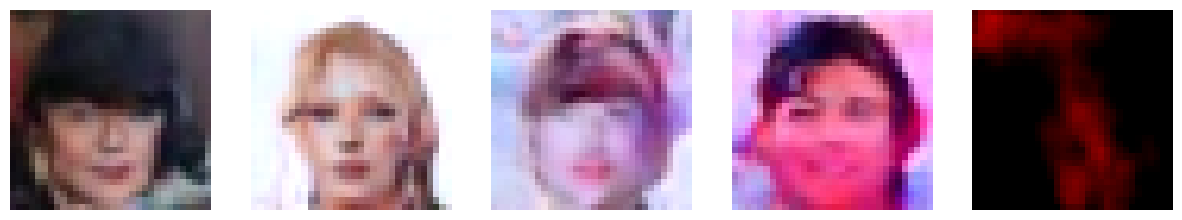

In [28]:
samples = sample_ddpm(model, betas, image_size=IMG_SIZE, n_samples=5, channels=3, device=device)
show(samples)

<div class="admonition success">
  <p class="admonition-title">Exercise</p>
  <p style="margin: 1em 0;">
     We got some ugly celebrity faces! Now it is your turn to train the model longer with increased sample size (e.g. 25-50K images), increased U-Net model depth (64-128-256-512). You will be amazed what this simple diffusion code can generate with mere scaling.
  </p>
</div>

## Conclusion

In this notebook, we implemented a minimal DDPM pipeline and showed how a simple supervised objective $(x_t,t)\mapsto \epsilon$ is sufficient to learn a generative model. The forward process gradually destroys structure by adding Gaussian noise, while the reverse process reconstructs it step by step by approximating the posterior $q(x_{t-1} \mid x_t, x_0)$. Sampling therefore does not rely on a direct mapping from noise to data, but on a sequence of small, local denoising updates that collectively approximate the data distribution. The implementation in this notebook is a minimal but complete foundation, from which more advanced ideas such as faster samplers, **score-based** formulations, and domain-specific applications can be explored.